##### Insurance Cost Prediction using Regression

##### Objective: Predict insurance charges using customer features.

## Dataset Features
- age
- bmi
- smoker
- children
- region
etc.

## Workflow
Data Cleaning → EDA → Assumption Testing → Modeling → Evaluation

#### Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


#### Load and assign Dataset

In [15]:
df=pd.read_csv("insurance projects.csv")

In [16]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


####  Data Cleaning & Preprocessing 

Checking missing values because null values can affect model performance.

In [17]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

describe the datset to know statistics behind the data

In [18]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


now here we are scouting the datatypes of the feature

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


if there is any duplicates we will drop that

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


checking the all the data is consistent or not 

In [22]:
for col in df.columns:
    print(col, df[col].nunique())

age 47
sex 2
bmi 548
children 6
smoker 2
region 4
charges 1337


#### EDA

In [23]:
import plotly.express as px
px.histogram(df,x='age',nbins=20,title='Age Distribution').show()

In [24]:
px.histogram(df, x="bmi", nbins=20, title="BMI Distribution").show()

In [25]:
px.histogram(df, x="charges", nbins=20, title="Charges Distribution").show()

In [26]:
px.bar(df['sex'].value_counts().reset_index(), x='sex', y='count', title="Sex Count")

In [27]:
px.bar(df['smoker'].value_counts().reset_index(), x='smoker', y='count', title="Smoker Count")

In [28]:
px.bar(df['region'].value_counts().reset_index(), x='region', y='count', title="Region Count")

In [29]:
px.scatter(df,x='age',y='charges',title='Age vs charges')

In [30]:
px.scatter(df, x="bmi", y="charges", title="BMI vs Charges")

In [31]:
px.scatter(df, x="children", y="charges", title="Children vs Charges")

In [32]:
px.box(df, x="smoker", y="charges", title="Charges by Smoker")


###  Assumption 1: There should be no outliers in the data.
### Check using boxplot.

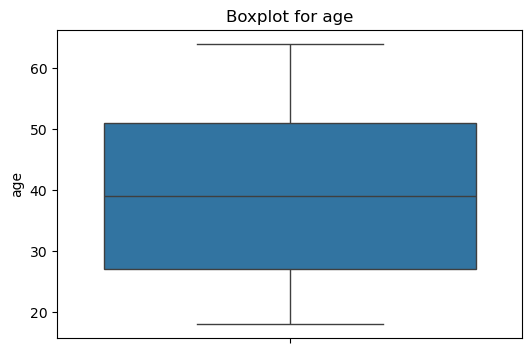

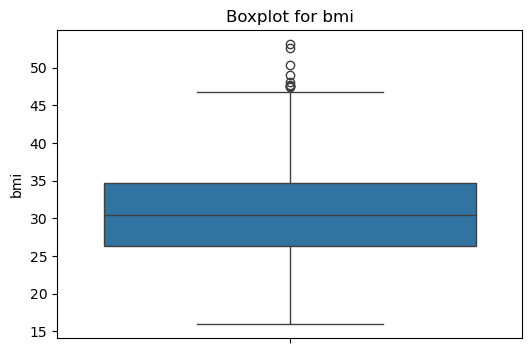

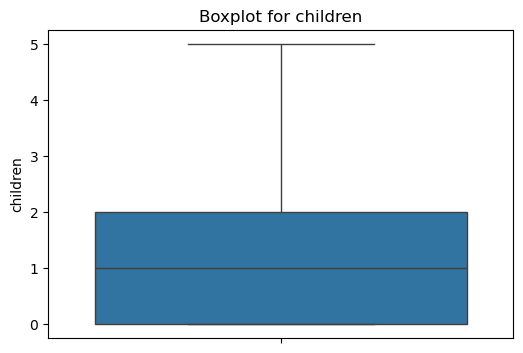

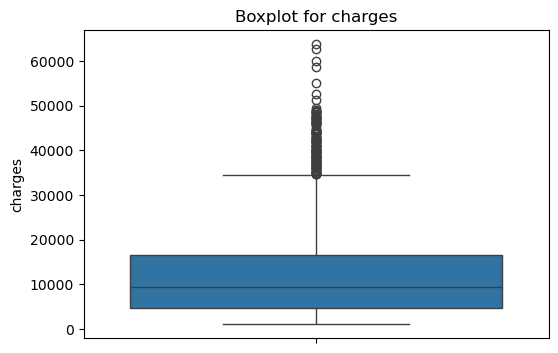

In [33]:
numeric_cols=['age','bmi', 'children', 'charges']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()

### Assumption 2:Assumption of Linearity:Every independent variable should have a
### linear relationship with the dependent variable.

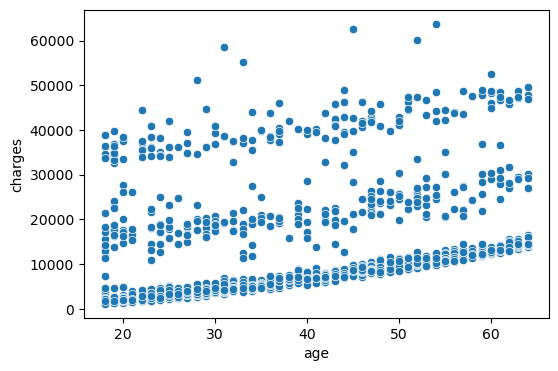

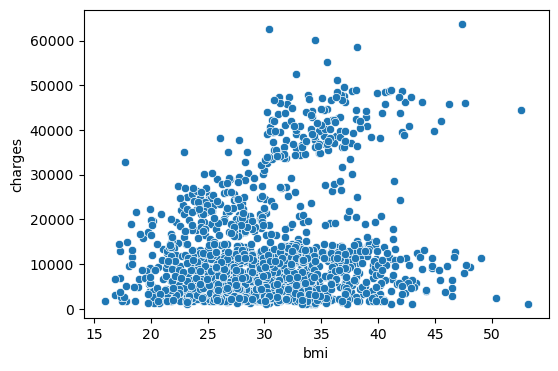

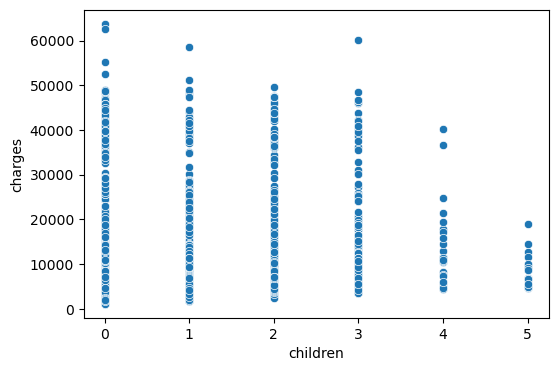

In [34]:
for col in ['age', 'bmi', 'children']:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col],y=df['charges'])
    plt.show()

### #Assumption 3: of Normality: The dependent variable should follow an
### approximate normal distribution

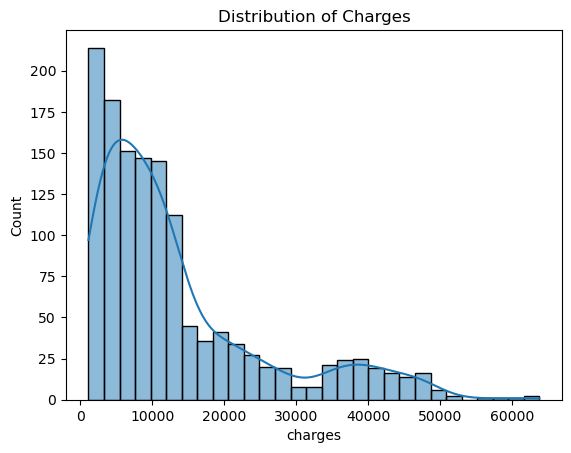

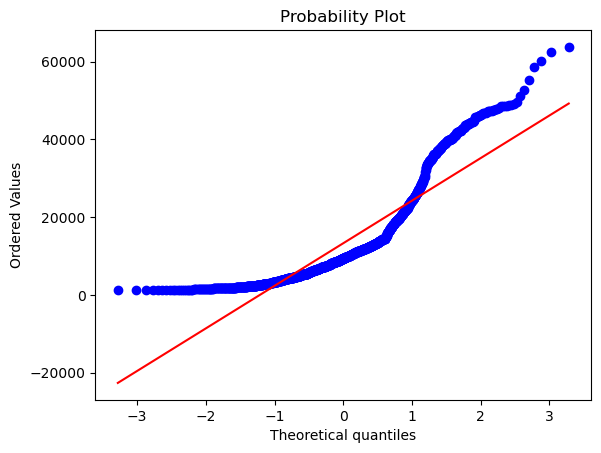

In [35]:
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Charges")
plt.show()

import scipy.stats as stats
stats.probplot(df['charges'], dist="norm", plot=plt)
plt.show()

##### here the charges feature is slightly right skewed and needed to transform it 

In [36]:
df['charges_log']=np.log1p(df['charges'])

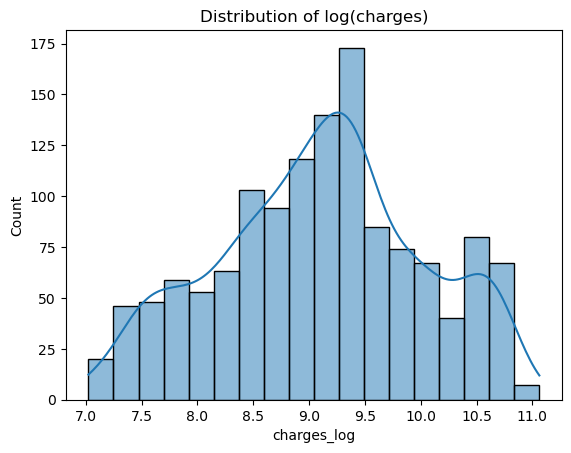

In [37]:
sns.histplot(df['charges_log'], kde=True)
plt.title("Distribution of log(charges)")
plt.show()

#### after applying log transformation the the charges feture become roughly normaly distributed and 
#### by doing these the outlier of charges also handled

### Encoding categoric feature

In [38]:
df['sex'] = df['sex'].map({'male':1, 'female':0})

In [39]:
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})

In [40]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [41]:
df

,age,sex,bmi,children,smoker,charges,charges_log,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,9.734236,False,False,True
1,18,1,33.770,1,0,1725.55230,7.453882,False,True,False
2,28,1,33.000,3,0,4449.46200,8.400763,False,True,False
3,33,1,22.705,0,0,21984.47061,9.998137,True,False,False
4,32,1,28.880,0,0,3866.85520,8.260455,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,9.268755,True,False,False
1334,18,0,31.920,0,0,2205.98080,7.699381,False,False,False
1335,18,0,36.850,0,0,1629.83350,7.396847,False,True,False
1336,21,0,25.800,0,0,2007.94500,7.605365,False,False,True


### assumption 4 checking Multicollinearity in data 

In [42]:
X = pd.get_dummies(df.drop('charges_log', axis=1), drop_first=True)
X = X.astype(float)

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

            feature        VIF
0               age   9.458623
1               sex   2.007425
2               bmi  11.476030
3          children   1.816399
4            smoker   4.022951
5           charges   7.964404
6  region_northwest   1.905902
7  region_southeast   2.276614
8  region_southwest   1.983546


In [43]:
df.drop('charges',axis=1,inplace=True)

In [44]:
X.drop('charges',axis=1,inplace=True)

In [45]:
y = df['charges_log']

### Splitting the data 

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [47]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape) 
print(y_test.shape)

(1069, 8)
(268, 8)
(1069,)
(268,)


### Building Models

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression
import pandas as pd


model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print('coefficent',model.coef_)

Intercept: 7.052521193910408
coefficent [ 0.03398961 -0.0767691   0.01314895  0.09913939  1.53733029 -0.04364934
 -0.12856217 -0.10122401]


In [49]:
y_pred=model.predict(X_test)

In [50]:
y_pred

array([ 8.93729181,  8.67016676,  9.51818498, 10.27272176,  8.60393505,
        9.204177  , 10.05206352,  8.01858825,  8.95328049,  9.27225545,
        9.35954966, 10.59664829, 10.14208872,  9.60321754,  8.94134584,
        8.97971442,  8.08737522, 10.17012885,  8.26816701,  8.39787474,
        8.03766677, 10.20434728,  9.3489262 , 10.20870807, 10.13504171,
        8.36313184, 10.61795512, 10.88252083,  9.22187642,  9.47224257,
        8.51467145,  9.13324168,  7.86477595,  9.34065086, 10.92012032,
        9.23360106,  8.46885689,  8.58830005, 10.46078282,  8.95544876,
        8.3236868 , 10.5132544 , 10.61645962,  9.23307295,  9.03299446,
        8.24224936,  8.1939741 ,  8.90514365,  8.40073853,  8.79630078,
        8.50786246,  8.86221563, 10.4828183 ,  7.96523682,  8.97110316,
        8.94455307,  9.17311372,  8.25380027, 10.07539194,  8.92618217,
        9.53129475,  8.66256058,  9.39182682,  7.93108155,  9.60393348,
        9.36453711,  8.85366552, 10.23895264,  9.42188705,  9.74

### Evaluate the Model

In [51]:
from sklearn.metrics import mean_squared_error, r2_score


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]  
p = X_test.shape[1]  
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)


print('mse',mse)
print("RMSE:", rmse)
print("R^2 Score:", r2)
print("Adjusted R^2:", r2_adj)


mse 0.15822472253428818
RMSE: 0.3977747132916925
R^2 Score: 0.8294786261333561
Adjusted R^2: 0.8242115566702937


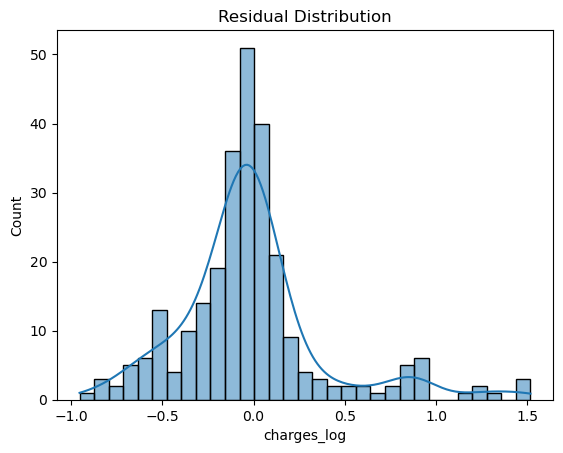

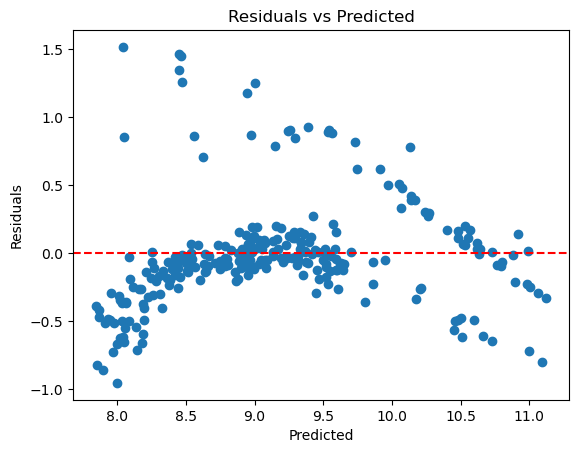

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()


#### Testing Data 

In [53]:
unseen_data = {
    "age": [22,28,19,35,42,31,55,47,50,29,
            24,33,46,53,39,30,57,21,44,48,
            26,37,52,41,60,34,23,49,54,25,
            38,27,45,36,43,51,20,32,58,40,
            33,47,59,24,37,29,56,22,61,45],

    "sex": [1,0,1,1,0,1,0,1,0,1,
            0,1,0,1,0,1,0,1,0,1,
            0,1,0,1,0,1,0,1,0,1,
            0,1,0,1,0,1,0,1,0,1,
            0,1,0,1,0,1,0,1,0,1],

    "bmi": [27.4,31.2,22.8,29.5,33.7,26.9,28.4,34.1,25.3,30.8,
            23.4,29.1,36.2,27.6,28.7,24.5,32.9,26.2,37.4,30.0,
            23.1,33.9,29.4,31.0,27.9,25.6,22.7,39.2,30.8,27.1,
            29.3,24.8,35.7,28.3,26.4,29.9,21.9,33.2,27.5,30.3,
            23.8,34.9,28.8,27.0,32.4,24.6,30.2,25.1,28.5,33.0],

    "children": [0,1,0,2,1,3,0,2,1,0,
                 0,2,4,1,3,0,2,1,2,3,
                 0,2,4,1,0,2,0,3,1,0,
                 3,0,4,2,1,3,0,1,2,0,
                 1,4,1,0,2,1,3,0,1,2],

    "smoker": [0,0,0,0,0,0,1,0,0,1,
               0,0,0,1,0,0,0,0,1,0,
               0,1,0,0,1,0,0,1,0,0,
               1,0,0,0,1,0,0,0,1,0,
               0,0,1,0,0,0,1,0,1,0],

    "region_northwest": [0,1,0,1,0,0,1,0,0,1,
                         0,1,0,1,0,0,1,0,0,1,
                         0,0,1,0,0,1,0,0,1,0,
                         0,1,0,0,1,0,0,1,0,0,
                         0,1,0,0,1,0,1,0,0,1],

    "region_southeast": [1,0,0,0,1,0,0,1,0,0,
                         1,0,0,0,1,0,0,1,0,0,
                         1,0,0,1,0,0,1,0,0,1,
                         0,0,1,0,0,1,0,0,1,0,
                         1,0,0,1,0,0,0,1,0,0],

    "region_southwest": [0,0,1,0,0,1,0,0,1,0,
                         0,0,1,0,0,1,0,0,1,0,
                         0,1,0,0,1,0,0,1,0,0,
                         1,0,0,1,0,0,1,0,0,1,
                         0,0,1,0,0,1,0,0,1,0]
}
Test_data=pd.DataFrame(unseen_data)
Test_data

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,22,1,27.4,0,0,0,1,0
1,28,0,31.2,1,0,1,0,0
2,19,1,22.8,0,0,0,0,1
3,35,1,29.5,2,0,1,0,0
4,42,0,33.7,1,0,0,1,0
5,31,1,26.9,3,0,0,0,1
6,55,0,28.4,0,1,1,0,0
7,47,1,34.1,2,0,0,1,0
8,50,0,25.3,1,0,0,0,1
9,29,1,30.8,0,1,1,0,0


In [54]:
y_test_pred_log = model.predict(Test_data)

In [55]:
y_test_pred = np.expm1(y_test_pred_log)

In [56]:
Test_data['Predicted_charges_log'] = y_test_pred_log
Test_data['Predicted_charges'] = y_test_pred

In [57]:
Test_data.head(10)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,Predicted_charges_log,Predicted_charges
0,22,1,27.4,0,0,0,1,0,7.955243,2849.480181
1,28,0,31.2,1,0,1,0,0,8.469968,4768.361784
2,19,1,22.8,0,0,0,0,1,7.820127,2489.221344
3,35,1,29.5,2,0,1,0,0,8.707912,6049.596450
4,42,0,33.7,1,0,0,1,0,8.893782,7285.524073
5,31,1,26.9,3,0,0,0,1,8.579331,5319.545560
6,55,0,28.4,0,1,1,0,0,10.789061,48486.491622
7,47,1,34.1,2,0,0,1,0,9.091360,8877.250841
8,50,0,25.3,1,0,0,0,1,9.082586,8799.693011
9,29,1,30.8,0,1,1,0,0,9.860120,19150.179838


In [58]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coeff_df.sort_values(by="Coefficient", ascending=False))


            Feature  Coefficient
4            smoker     1.537330
3          children     0.099139
0               age     0.033990
2               bmi     0.013149
5  region_northwest    -0.043649
1               sex    -0.076769
7  region_southwest    -0.101224
6  region_southeast    -0.128562


### Tunning the Data 

In [59]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
params = {'alpha':[0.01, 0.1, 1, 10, 100]}  
ridge_cv = GridSearchCV(ridge, params, cv=5, scoring='r2')
ridge_cv.fit(X_train, y_train)

print("Best alpha:", ridge_cv.best_params_)
print("Best R^2:", ridge_cv.best_score_)

# Predict
#y_pred_ridge = ridge_cv.predict(X_test)

Best alpha: {'alpha': 1}
Best R^2: 0.7463781536922552


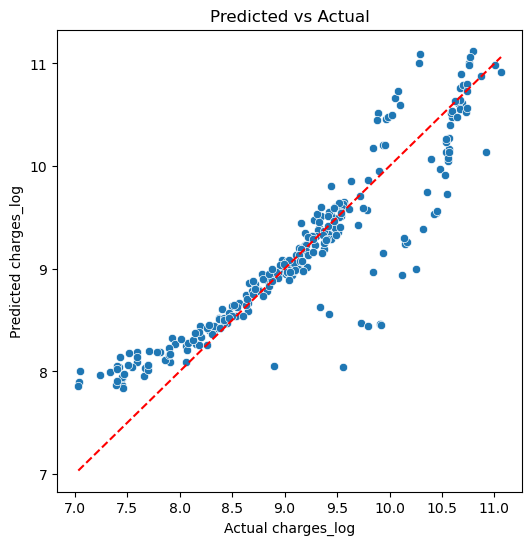

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual charges_log")
plt.ylabel("Predicted charges_log")
plt.title("Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal line
plt.show()


In [63]:
Test_data.head(10)
Test_data.to_csv("predictions_unseen_50rows.csv", index=False)

## Conclusion

- Smoking strongly affects charges
- Log transformation improved distribution
- Regression achieved 74.63% R² score
- Model can estimate insurance costs reasonably well